In [1]:
import numpy as np
from matplotlib import pyplot as plt
from time import time
import PT_model
from PT_model import Acoustic_2D_Cartesian_Grid
import PT_data_classes
from copy import copy
import PT_data 
import PT_routines

In [2]:
model = PT_model.load_model("Box_Model")
model.model_params.c[:, :] = 1750.0
model.save_model(path = "Model_Init")

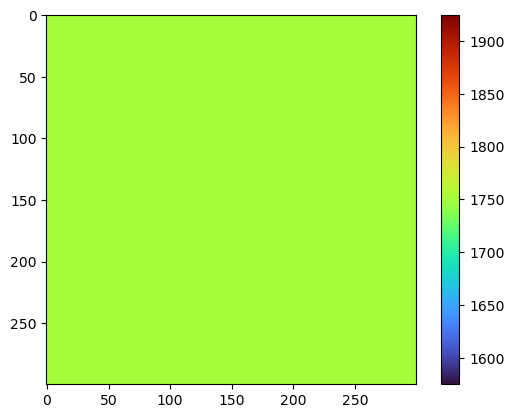

In [3]:
model = PT_model.load_model("Model_Init")

plt.imshow(model.model_params.c, cmap="turbo")
plt.colorbar()

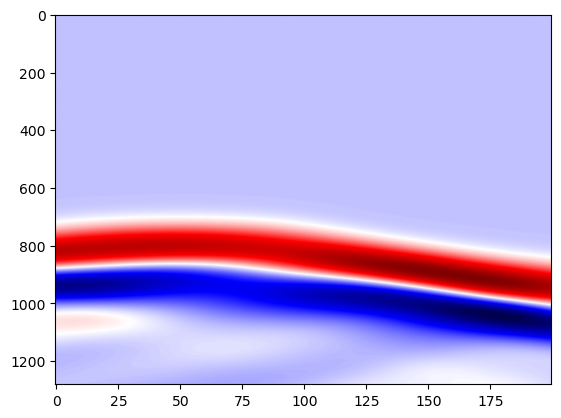

In [4]:
# load marmousi data

obs_data_set = PT_data.load_data_set("Box_Data")

SG_plt = obs_data_set.shot_gathers[1].gather
plt.imshow(SG_plt, aspect="auto", cmap="seismic")

# create save indice
save_inds = np.arange(0, obs_data_set.shot_gathers[0].aquisition_params.Nt+1).tolist()
save_inds = save_inds[::5]

In [5]:
# set preprocessing and adjiont parameters

preprocess_params = PT_data_classes.Preprocess_params(mute=False, 
                                                         filter=None,
                                                         filter_bounds=[5],
                                                         normalize=False)

adjoint_params = PT_data_classes.Adjoint_params(adjoint_source="L2", additonal_parmas=[])


In [6]:
Ns = len(obs_data_set.shot_gathers)

model_list = []
aquisition_params_list = []
preprocess_params_list = []
adjoint_params_list = []
save_inds_list = []
SG_OBS_list = []

for i in range(Ns): 
    model_list.append(model)
    aquisition_params_list.append(obs_data_set.shot_gathers[i].aquisition_params)
    preprocess_params_list.append(preprocess_params)
    adjoint_params_list.append(adjoint_params)
    save_inds_list.append(save_inds)
    SG_OBS_list.append(obs_data_set.shot_gathers[i])


In [7]:

OUT = PT_routines.Compute_Kernel_Parallel(model_list=model_list,
                                          aquisition_params_list=aquisition_params_list,
                                          preprocess_params_lsit=preprocess_params_list,
                                          adjoint_params_list=adjoint_params_list,
                                          save_inds_list=save_inds_list,
                                          SG_OBS_list=SG_OBS_list)

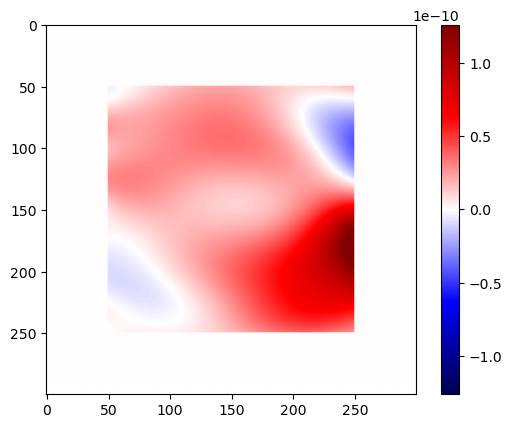

In [8]:
I = np.zeros((model.model_params.Nz, model.model_params.Nx), dtype=np.float32)
P = np.zeros((model.model_params.Nz, model.model_params.Nx), dtype=np.float32)

for i in range(len(OUT)):
	SK, HK = OUT[i][0:2]
	I += SK
	P += HK

G = I / P
G[0:50, :] = 0.0
G[250:, :] = 0.0
G[:, 0:50] = 0.0
G[:, 250:] = 0.0

plt.imshow(G, cmap="seismic", vmin=-0.9*np.max(np.abs(G)), vmax=0.9*np.max(np.abs(G)))
plt.colorbar()

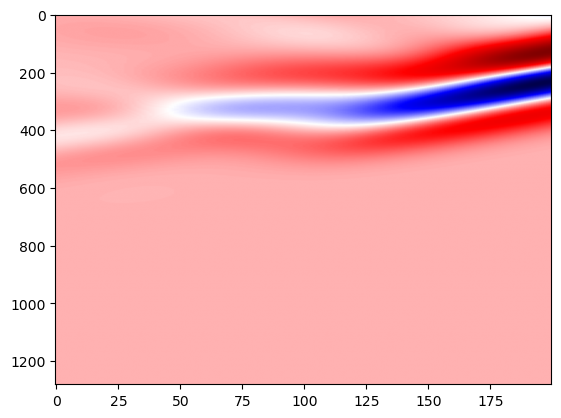

In [9]:
plt.imshow(OUT[0][2], cmap="seismic", aspect="auto")

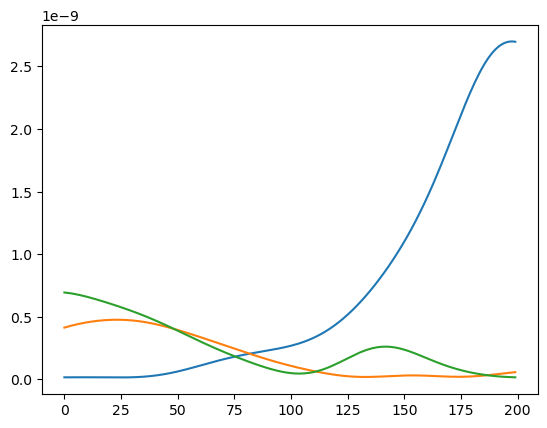

In [10]:
plt.plot(OUT[0][3])
plt.plot(OUT[-2][3])
plt.plot(OUT[-1][3])